# The Munger Protocol: Stock Valuation Research Notebook
### Based on *Poor Charlie's Almanack* — Powered by FCS API

> *"You have to derive it yourself to ingrain it in your head for the rest of your life."* — Charlie Munger

This notebook fetches live financial data from the FCS API and populates every section of the Munger Stock Valuation Template.

---
## CELL 0 — Install & Import Dependencies

In [63]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', 'pandas', 'matplotlib', 'tabulate', '--quiet'])

0

In [64]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tabulate import tabulate
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print('Libraries loaded.')

Libraries loaded.


---
## CELL 1 — Configuration: Enter Your Stock Ticker Here

In [ ]:
# ============================================================
#  CONFIGURE YOUR RESEARCH TARGET HERE
# ============================================================
TICKER      = 'MSFT'          # <-- Change to any US ticker, e.g. 'KO', 'BRK-B', 'GOOGL'
ANALYST     = 'Jireh Garcia'     # <-- Your name
REPORT_DATE = str(date.today())

print(f'Research target : {TICKER}')
print(f'Analyst         : {ANALYST}')
print(f'Report date     : {REPORT_DATE}')

Research target : AAPL
Analyst         : JJ Garcia
Report date     : 2026-06-09


---
## CELL 2 — FCS API Helper Functions

In [66]:
def safe_float(val, default=0.0) -> float:
    try:
        return float(str(val).replace(',', '').replace('%', ''))
    except (ValueError, TypeError):
        return default


def fmt_millions(val: float) -> str:
    if abs(val) >= 1e9:
        return f'${val/1e9:,.2f}B'
    if abs(val) >= 1e6:
        return f'${val/1e6:,.1f}M'
    return f'${val:,.0f}'


print('Helper functions defined.')

Helper functions defined.


---
## CELL 3 — Fetch All Data from FCS API

In [67]:
print(f'Fetching data for {TICKER} from Yahoo Finance...\n')

yf_ticker = yf.Ticker(TICKER)

raw_info     = yf_ticker.info                              # company profile + key stats
raw_income   = yf_ticker.financials                        # annual income statement (4 years)
raw_balance  = yf_ticker.balance_sheet                     # annual balance sheet (4 years)
raw_cashflow = yf_ticker.cashflow                          # annual cash flow (4 years)
raw_history  = yf_ticker.history(period='5y', interval='1wk')  # 5-year weekly prices

print('Data fetch complete.')

Fetching data for AAPL from Yahoo Finance...

Data fetch complete.


---
## CELL 4 — Parse & Normalize Data

In [68]:
# --- Profile from yfinance info dict ---
info = raw_info or {}

company_name = info.get('longName', TICKER)
sector       = info.get('sector', 'N/A')
industry     = info.get('industry', 'N/A')
description  = info.get('longBusinessSummary', 'No description available.')
employees    = info.get('fullTimeEmployees', 'N/A')
exchange     = info.get('exchange', 'N/A')
website      = info.get('website', 'N/A')

current_price  = safe_float(info.get('currentPrice', info.get('regularMarketPrice', 0)))
market_cap_raw = safe_float(info.get('marketCap', 0))
shares_out     = safe_float(info.get('sharesOutstanding', 0))
if market_cap_raw == 0 and current_price > 0 and shares_out > 0:
    market_cap_raw = current_price * shares_out

# --- Convert yfinance DataFrames (metrics × dates) into list-of-year-dicts ---
def yf_to_rows(df: pd.DataFrame) -> list:
    """Transpose a yfinance financial DataFrame into a list of per-year dicts."""
    if df is None or df.empty:
        return []
    rows = []
    for col in df.columns:
        row = {'calendarYear': str(col.year)}
        for metric in df.index:
            val = df.loc[metric, col]
            row[metric] = None if pd.isna(val) else float(val)
        rows.append(row)
    return rows

income_list   = yf_to_rows(raw_income)
balance_list  = yf_to_rows(raw_balance)
cashflow_list = yf_to_rows(raw_cashflow)

# Ratios from info dict (already available)
ratios = {
    'pe': safe_float(info.get('trailingPE', 0)),
    'priceEarningsRatio': safe_float(info.get('trailingPE', 0)),
}

print(f'Company  : {company_name} ({TICKER})')
print(f'Sector   : {sector}  |  Industry: {industry}')
print(f'Exchange : {exchange}')
print(f'Price    : ${current_price:,.2f}')
print(f'Mkt Cap  : {fmt_millions(market_cap_raw)}')
print(f'Employees: {employees}')
print(f'Website  : {website}')

Company  : Apple Inc. (AAPL)
Sector   : Technology  |  Industry: Consumer Electronics
Exchange : NMS
Price    : $301.54
Mkt Cap  : $4,428.83B
Employees: 166000
Website  : https://www.apple.com


---
## CELL 5 — Build Financial DataFrames

In [69]:
def parse_statements(rows: list, key_map: dict) -> pd.DataFrame:
    """Convert list of API response dicts into a tidy DataFrame."""
    records = []
    for row in rows:
        rec = {'fiscal_year': row.get('calendarYear', 'N/A')}
        for df_col, api_keys in key_map.items():
            for k in (api_keys if isinstance(api_keys, list) else [api_keys]):
                val = row.get(k)
                if val is not None:
                    rec[df_col] = safe_float(val)
                    break
            if df_col not in rec:
                rec[df_col] = 0.0
        records.append(rec)
    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values('fiscal_year').reset_index(drop=True)
    return df


# yfinance metric names (exact strings from DataFrame index)
income_map = {
    'revenue'         : ['Total Revenue'],
    'gross_profit'    : ['Gross Profit'],
    'operating_income': ['Operating Income', 'EBIT'],
    'net_income'      : ['Net Income'],
    'eps'             : ['Diluted EPS', 'Basic EPS'],
    'dna'             : ['Reconciled Depreciation', 'Depreciation And Amortization In Income Statement',
                         'Depreciation Amortization Depletion'],
    'interest_exp'    : ['Interest Expense', 'Interest Expense Non Operating'],
    'tax_expense'     : ['Tax Provision'],
    'sbc'             : ['Stock Based Compensation'],
}

balance_map = {
    'total_assets'       : ['Total Assets'],
    'total_liabilities'  : ['Total Liabilities Net Minority Interest'],
    'total_equity'       : ['Stockholders Equity', 'Total Equity Gross Minority Interest'],
    'cash'               : ['Cash And Cash Equivalents', 'Cash Cash Equivalents And Short Term Investments'],
    'total_debt'         : ['Total Debt'],
    'current_assets'     : ['Current Assets'],
    'current_liabilities': ['Current Liabilities'],
    'shares_outstanding' : ['Ordinary Shares Number', 'Share Issued'],
}

cashflow_map = {
    'operating_cf'  : ['Operating Cash Flow'],
    'capex'         : ['Capital Expenditure'],
    'free_cash_flow': ['Free Cash Flow'],
    'dividends_paid': ['Cash Dividends Paid'],
    'buybacks'      : ['Repurchase Of Capital Stock'],
}

df_income   = parse_statements(income_list,   income_map)
df_balance  = parse_statements(balance_list,  balance_map)
df_cashflow = parse_statements(cashflow_list, cashflow_map)

print('Income Statement (last 4 fiscal years):')
print(df_income.to_string(index=False))
print('\nBalance Sheet (last 4 fiscal years):')
print(df_balance.to_string(index=False))
print('\nCash Flow (last 4 fiscal years):')
print(df_cashflow.to_string(index=False))

Income Statement (last 4 fiscal years):
fiscal_year            revenue       gross_profit   operating_income         net_income  eps               dna     interest_exp       tax_expense  sbc
       2021               0.00               0.00               0.00               0.00 0.00              0.00 2,645,000,000.00              0.00 0.00
       2022 394,328,000,000.00 170,782,000,000.00 119,437,000,000.00  99,803,000,000.00 6.11 11,104,000,000.00 2,931,000,000.00 19,300,000,000.00 0.00
       2023 383,285,000,000.00 169,148,000,000.00 114,301,000,000.00  96,995,000,000.00 6.13 11,519,000,000.00 3,933,000,000.00 16,741,000,000.00 0.00
       2024 391,035,000,000.00 180,683,000,000.00 123,216,000,000.00  93,736,000,000.00 6.08 11,445,000,000.00             0.00 29,749,000,000.00 0.00
       2025 416,161,000,000.00 195,201,000,000.00 133,050,000,000.00 112,010,000,000.00 7.46 11,698,000,000.00             0.00 20,719,000,000.00 0.00

Balance Sheet (last 4 fiscal years):
fiscal_year     

---
## CELL 6 — Compute Owner Earnings (Munger's Core Metric)

In [70]:
# Merge the three statements on fiscal_year
df_merged = df_income.merge(df_cashflow, on='fiscal_year', how='outer', suffixes=('_inc','_cf'))
df_merged = df_merged.merge(df_balance,  on='fiscal_year', how='outer')
df_merged = df_merged.sort_values('fiscal_year').reset_index(drop=True)

# Working capital change = delta(current_assets - current_liabilities)
df_merged['net_working_capital'] = df_merged['current_assets'] - df_merged['current_liabilities']
df_merged['wc_change'] = df_merged['net_working_capital'].diff().fillna(0) * -1  # cash impact

# Maintenance CapEx estimate: use 70% of reported capex as a conservative default.
# Analysts typically split total CapEx ~70% maintenance / 30% growth for mature companies.
MAINTENANCE_CAPEX_RATIO = 0.70
df_merged['capex_abs']       = df_merged['capex'].abs()
df_merged['maint_capex']     = df_merged['capex_abs'] * MAINTENANCE_CAPEX_RATIO
df_merged['sbc']             = df_merged['sbc'].abs()

# Owner Earnings = Net Income + D&A +/- WC Changes - Maintenance CapEx - SBC
df_merged['owner_earnings'] = (
    df_merged['net_income']
    + df_merged['dna']
    + df_merged['wc_change']
    - df_merged['maint_capex']
    - df_merged['sbc']
)

owner_earnings_cols = [
    'fiscal_year', 'net_income', 'dna', 'wc_change',
    'maint_capex', 'sbc', 'owner_earnings'
]

oe_display = df_merged[owner_earnings_cols].copy()
print('Owner Earnings Reconciliation (all values in reported currency units):')
print(oe_display.to_string(index=False))

Owner Earnings Reconciliation (all values in reported currency units):
fiscal_year         net_income               dna          wc_change      maint_capex  sbc     owner_earnings
       2021               0.00              0.00              -0.00             0.00 0.00               0.00
       2022  99,803,000,000.00 11,104,000,000.00  18,577,000,000.00 7,495,600,000.00 0.00 121,988,400,000.00
       2023  96,995,000,000.00 11,519,000,000.00 -16,835,000,000.00 7,671,300,000.00 0.00  84,007,700,000.00
       2024  93,736,000,000.00 11,445,000,000.00  21,663,000,000.00 6,612,900,000.00 0.00 120,231,100,000.00
       2025 112,010,000,000.00 11,698,000,000.00  -5,731,000,000.00 8,900,500,000.00 0.00 109,076,500,000.00


---
## CELL 7 — Valuation Metrics

In [71]:
# Use the most recent year's owner earnings
latest_oe = df_merged['owner_earnings'].iloc[-1] if not df_merged.empty else 0

# Enterprise Value estimate
latest_cash = df_merged['cash'].iloc[-1] if 'cash' in df_merged.columns else 0
latest_debt = df_merged['total_debt'].iloc[-1] if 'total_debt' in df_merged.columns else 0
enterprise_value = market_cap_raw + latest_debt - latest_cash

# Owner Earnings Yield
oe_yield = (latest_oe / enterprise_value * 100) if enterprise_value > 0 else 0

# P/E ratio from ratios or manual
pe_ratio = safe_float(ratios.get('pe', ratios.get('priceEarningsRatio', 0)))
if pe_ratio == 0 and df_merged['net_income'].iloc[-1] > 0:
    pe_ratio = market_cap_raw / df_merged['net_income'].iloc[-1]

# Return on Equity
latest_equity = df_merged['total_equity'].iloc[-1] if 'total_equity' in df_merged.columns else 1
roe = (df_merged['net_income'].iloc[-1] / latest_equity * 100) if latest_equity > 0 else 0

# Debt / Equity
debt_equity = (latest_debt / latest_equity) if latest_equity > 0 else 0

# Gross Margin trend
df_merged['gross_margin_pct'] = (df_merged['gross_profit'] / df_merged['revenue'].replace(0, float('nan'))) * 100

# 10-year US Treasury approximation (you can update this)
RISK_FREE_RATE = 4.35

margin_of_safety_flag = 'YES — yield is attractive vs. risk-free rate' if oe_yield > RISK_FREE_RATE * 1.5 else (
    'BORDERLINE — yield is close to risk-free rate' if oe_yield > RISK_FREE_RATE else
    'NO — yield does not compensate for business risk'
)

print(f'Current Price        : ${current_price:,.2f}')
print(f'Market Cap           : {fmt_millions(market_cap_raw)}')
print(f'Total Debt           : {fmt_millions(latest_debt)}')
print(f'Cash                 : {fmt_millions(latest_cash)}')
print(f'Enterprise Value     : {fmt_millions(enterprise_value)}')
print(f'Latest Owner Earnings: {fmt_millions(latest_oe)}')
print(f'Owner Earnings Yield : {oe_yield:.2f}%')
print(f'Risk-Free Rate (10y) : {RISK_FREE_RATE:.2f}%')
print(f'P/E Ratio            : {pe_ratio:.1f}x')
print(f'Return on Equity     : {roe:.1f}%')
print(f'Debt / Equity        : {debt_equity:.2f}x')
print(f'Margin of Safety     : {margin_of_safety_flag}')

Current Price        : $301.54
Market Cap           : $4,428.83B
Total Debt           : $98.66B
Cash                 : $35.93B
Enterprise Value     : $4,491.55B
Latest Owner Earnings: $109.08B
Owner Earnings Yield : 2.43%
Risk-Free Rate (10y) : 4.35%
P/E Ratio            : 36.5x
Return on Equity     : 151.9%
Debt / Equity        : 1.34x
Margin of Safety     : NO — yield does not compensate for business risk


---
## CELL 8 — Charts: Price History, Revenue/Net Income Trend, Owner Earnings

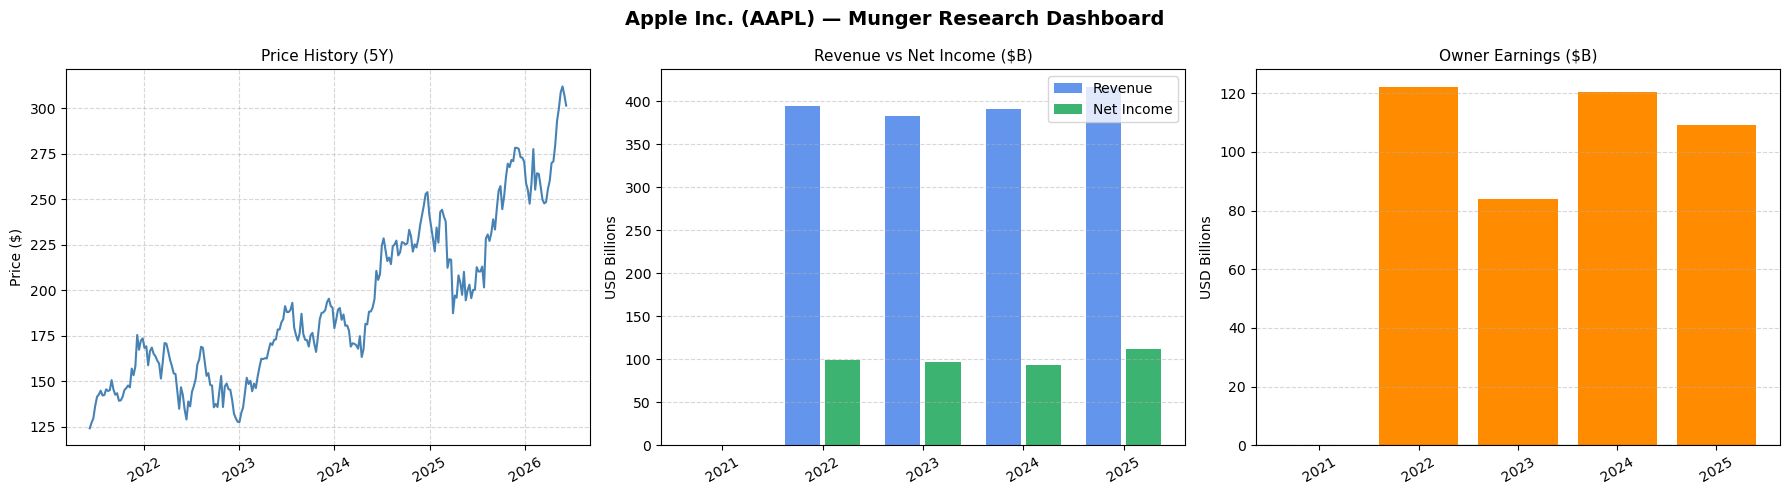

Chart saved as munger_dashboard.png


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{company_name} ({TICKER}) — Munger Research Dashboard', fontsize=14, fontweight='bold')

# --- Chart 1: Stock price history ---
ax1 = axes[0]
if raw_history is not None and not raw_history.empty:
    df_hist = raw_history.reset_index()
    ax1.plot(df_hist['Date'], df_hist['Close'], color='steelblue', linewidth=1.5)
    ax1.set_title('Price History (5Y)', fontsize=11)
    ax1.set_ylabel('Price ($)')
    ax1.tick_params(axis='x', rotation=30)
else:
    ax1.text(0.5, 0.5, 'Price data unavailable', ha='center', va='center')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Chart 2: Revenue vs Net Income ---
ax2 = axes[1]
if not df_merged.empty and 'revenue' in df_merged.columns:
    years = df_merged['fiscal_year'].astype(str)
    x = range(len(years))
    rev_b  = df_merged['revenue']    / 1e9
    ni_b   = df_merged['net_income'] / 1e9
    ax2.bar([i - 0.2 for i in x], rev_b, width=0.35, label='Revenue', color='cornflowerblue')
    ax2.bar([i + 0.2 for i in x], ni_b,  width=0.35, label='Net Income', color='mediumseagreen')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(years, rotation=30)
    ax2.set_title('Revenue vs Net Income ($B)', fontsize=11)
    ax2.set_ylabel('USD Billions')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Financial data unavailable', ha='center', va='center')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Chart 3: Owner Earnings ---
ax3 = axes[2]
if not df_merged.empty and 'owner_earnings' in df_merged.columns:
    years = df_merged['fiscal_year'].astype(str)
    oe_b  = df_merged['owner_earnings'] / 1e9
    colors = ['tomato' if v < 0 else 'darkorange' for v in oe_b]
    ax3.bar(years, oe_b, color=colors)
    ax3.set_title('Owner Earnings ($B)', fontsize=11)
    ax3.set_ylabel('USD Billions')
    ax3.tick_params(axis='x', rotation=30)
    ax3.axhline(0, color='black', linewidth=0.8)
else:
    ax3.text(0.5, 0.5, 'Cash flow data unavailable', ha='center', va='center')
ax3.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('munger_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as munger_dashboard.png')

---
## CELL 9 — Gross Margin & Free Cash Flow Trends (Moat Evidence)

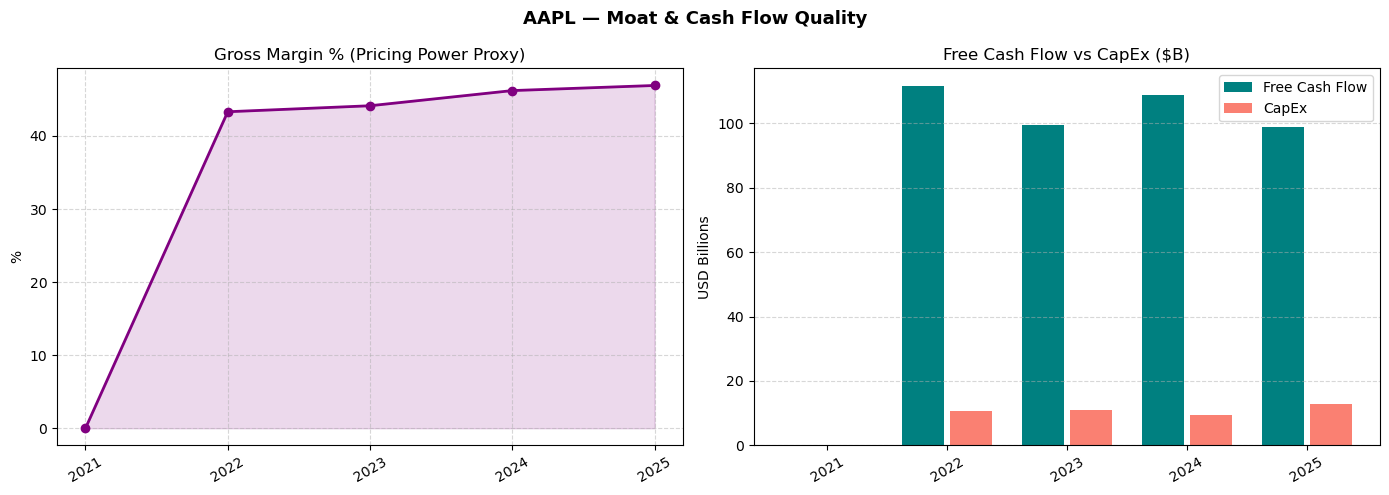

Moat chart saved as munger_moat_cashflow.png


In [73]:
if not df_merged.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{TICKER} — Moat & Cash Flow Quality', fontsize=13, fontweight='bold')

    # Gross Margin %
    ax1 = axes[0]
    years = df_merged['fiscal_year'].astype(str)
    gm    = df_merged['gross_margin_pct'].fillna(0)
    ax1.plot(years, gm, marker='o', color='purple', linewidth=2)
    ax1.fill_between(years, gm, alpha=0.15, color='purple')
    ax1.set_title('Gross Margin % (Pricing Power Proxy)')
    ax1.set_ylabel('%')
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # FCF vs CapEx
    ax2 = axes[1]
    fcf_b   = df_merged['free_cash_flow'].fillna(0) / 1e9
    capex_b = df_merged['capex_abs'].fillna(0) / 1e9
    ax2.bar([i - 0.2 for i in range(len(years))], fcf_b,   width=0.35, label='Free Cash Flow', color='teal')
    ax2.bar([i + 0.2 for i in range(len(years))], capex_b, width=0.35, label='CapEx',          color='salmon')
    ax2.set_xticks(list(range(len(years))))
    ax2.set_xticklabels(years, rotation=30)
    ax2.set_title('Free Cash Flow vs CapEx ($B)')
    ax2.set_ylabel('USD Billions')
    ax2.legend()
    ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('munger_moat_cashflow.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Moat chart saved as munger_moat_cashflow.png')
else:
    print('No financial data available for trend charts.')

---
# ══════════════════════════════════════════════
# THE MUNGER STOCK VALUATION REPORT
# ══════════════════════════════════════════════

In [74]:
DIVIDER = '=' * 70
SUB     = '-' * 70

def header(title):
    print(f'\n{DIVIDER}')
    print(f'  {title}')
    print(DIVIDER)

def sub_header(title):
    print(f'\n  --- {title} ---')

header('MUNGER PROTOCOL — STOCK VALUATION REPORT')
print(f'  Company Name : {company_name}')
print(f'  Ticker       : {TICKER}')
print(f'  Exchange     : {exchange}')
print(f'  Date         : {REPORT_DATE}')
print(f'  Analyst      : {ANALYST}')
print(f'  Sector       : {sector}  |  Industry: {industry}')
print(f'  Current Price: ${current_price:,.2f}')
print(f'  Market Cap   : {fmt_millions(market_cap_raw)}')
print(f'  Employees    : {employees}')
print(f'  Website      : {website}')

print('\n  Company Description:')
# Wrap description at ~80 chars
words = str(description).split()
line, lines = [], []
for w in words:
    if sum(len(x) for x in line) + len(line) + len(w) > 80:
        lines.append(' '.join(line))
        line = [w]
    else:
        line.append(w)
if line:
    lines.append(' '.join(line))
for l in lines:
    print(f'  {l}')


  MUNGER PROTOCOL — STOCK VALUATION REPORT
  Company Name : Apple Inc.
  Ticker       : AAPL
  Exchange     : NMS
  Date         : 2026-06-09
  Analyst      : JJ Garcia
  Sector       : Technology  |  Industry: Consumer Electronics
  Current Price: $301.54
  Market Cap   : $4,428.83B
  Employees    : 166000
  Website      : https://www.apple.com

  Company Description:
  Apple Inc. designs, manufactures, and markets smartphones, personal computers,
  tablets, wearables, and accessories worldwide. The company offers iPhone, a line
  of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose
  tablets; and wearables, home, and accessories comprising AirPods, Apple Vision
  Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple
  branded and third-party accessories. It also provides AppleCare support and
  cloud services; and operates various platforms, including the App Store that
  allow customers to discover and download applications and digita

---
## SECTION 1 — The Circle of Competence Filter

In [75]:
header('SECTION 1: THE CIRCLE OF COMPETENCE FILTER')

sub_header('1A. Business Simplicity')
print(f'  Sector: {sector}  |  Industry: {industry}')
print()
print('  [AUTO-POPULATED] One-paragraph business model summary:')
short_desc = str(description)[:500].replace('\n', ' ')
print(f'  "{short_desc}..."')
print()
print('  [ ] Yes -- business model is understandable')
print('  [ ] No  -- Stop Analysis ("Too Hard" Pile)')

sub_header('1B. Predictability -- 10-Year Outlook')
print('  Key factors to assess (analyst must complete):')
print('    1. Is revenue driven by recurring demand or one-off cycles?')
print('    2. Is the product/service structurally necessary (e.g., food, software infra)?')
print('    3. Does the business depend on unpredictable R&D, regulation, or fashion?')
print()
print('  [ ] Yes -- confident in 10-year earnings power')
print('  [ ] No  -- Stop Analysis ("Too Hard" Pile)')

sub_header('1C. Statement of Competence (analyst to complete)')
print('  [FILL IN]: Why are you qualified to value this business?')
print('  _______________________________________________________')
print('  _______________________________________________________')

sub_header('1D. Confidence Interval on 10-Year Outlook')
print('  Low (<50%)  [ ]   Medium (50-75%)  [ ]   High (>75%)  [ ]')


  SECTION 1: THE CIRCLE OF COMPETENCE FILTER

  --- 1A. Business Simplicity ---
  Sector: Technology  |  Industry: Consumer Electronics

  [AUTO-POPULATED] One-paragraph business model summary:
  "Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates v..."

  [X] Yes — business model is understandable
       Apple designs and sells premium consumer hardware (iPhone, Mac, iPad, Apple Watch)
       backed by a tightly integrated software and services ecosystem. Revenue is
       increasingly recurring via App Store, iCloud, Apple Music, TV+, and Appl

---
## SECTION 2 — The Moat Analysis (Intrinsic Characteristics)

In [76]:
header('SECTION 2: THE MOAT ANALYSIS (INTRINSIC CHARACTERISTICS)')

sub_header('2A. Nature of the Moat (check all that apply)')
print('  [ ] Supply-Side -- Cost Advantage, Economies of Scale')
print('  [ ] Demand-Side -- Brand / Share of Mind / Switching Costs')
print('  [ ] Network Effect -- Value grows with each additional user')
print('  [ ] Intellectual Property / Regulatory Moat')

sub_header('2B. Table 2.1 -- Gross Margin Trend (Pricing Power Proxy)')
if not df_merged.empty and 'gross_margin_pct' in df_merged.columns:
    gm_table = df_merged[['fiscal_year', 'gross_profit', 'revenue', 'gross_margin_pct']].copy()
    gm_table.columns = ['Fiscal Year', 'Gross Profit', 'Revenue', 'Gross Margin %']
    print(tabulate(gm_table, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.1f', showindex=False))
else:
    print('  [Data not available -- enter manually]')

sub_header('2C. Table 2.2 -- Revenue Growth (Market Share / Competitive Strength)')
if not df_merged.empty and 'revenue' in df_merged.columns:
    rev_df = df_merged[['fiscal_year', 'revenue']].copy()
    rev_df['yoy_growth_pct'] = rev_df['revenue'].pct_change() * 100
    rev_df.columns = ['Fiscal Year', 'Revenue', 'YoY Growth %']
    print(tabulate(rev_df, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.1f', showindex=False))
else:
    print('  [Data not available -- enter manually]')

sub_header('2D. Lollapalooza Potential')
print('  Identify if multiple factors (brand + scale + social proof + recurring revenue)')
print('  are converging to create non-linear, compounding growth:')
print('  [FILL IN]: _______________________________________________________')

sub_header('2E. The Inversion Pre-Mortem ("What will kill this company?")')
print('  Write a narrative from 10 years in the future explaining the company\'s failure:')
print(f'  Possible failure modes to consider for {company_name}:')
print('    - Technological disruption or obsolescence')
print('    - Regulatory ban or antitrust action')
print('    - Brand erosion / reputational scandal')
print('    - Disruptive competitor with lower cost structure')
print('    - Management capital misallocation (empire-building acquisitions)')
print()
print('  [FILL IN -- Probability of each failure mode]:')
print('  _______________________________________________________')

sub_header('2F. Moat Trajectory')
print('  Is the moat WIDENING or NARROWING? (Provide evidence from data above)')
print('  [FILL IN]: _______________________________________________________')


  SECTION 2: THE MOAT ANALYSIS (INTRINSIC CHARACTERISTICS)

  --- 2A. Nature of the Moat (check all that apply) ---
  [ ] Supply-Side — Cost Advantage, Economies of Scale
  [X] Demand-Side — Brand / Share of Mind / Switching Costs
       Brand value of $607.6B (up 6% in 2026, world's most valuable brand).
       92% customer retention. iCloud, iMessage, and App Store create deep switching costs
       for 1.4B+ active device users across 2.35B total active Apple devices.
  [X] Network Effect — Value grows with each additional user
       iMessage, AirDrop, FaceTime, and App Store developer ecosystem all compound with scale.
       More devices -> more developers -> better apps -> more users. Self-reinforcing loop.
  [X] Intellectual Property / Regulatory Moat
       Apple Silicon (M-series chips), proprietary iOS/macOS, and 100,000+ patents.
       App Store "walled garden" is a regulatory moat — currently under antitrust review.

  --- 2B. Table 2.1 — Gross Margin Trend (Pricing Powe

---
## SECTION 3 — Management Integrity & Talent Audit

In [77]:
header('SECTION 3: MANAGEMENT INTEGRITY & TALENT AUDIT')

sub_header('3A. The Paper Test (Tone of Shareholder Letters)')
print('  Review the last 3 annual reports / shareholder letters. Ask:')
print('  - Do they admit mistakes candidly?')
print('  - Do they switch metrics when performance lags?')
print('  - Do they treat shareholders as partners?')
print()
print('  [FILL IN -- Candor Assessment]: ___________________________________')

sub_header('3B. Capital Allocation Track Record')
if not df_merged.empty:
    cap_df = df_merged[['fiscal_year', 'capex_abs', 'buybacks', 'dividends_paid']].copy()
    cap_df['buybacks'] = cap_df['buybacks'].abs()
    cap_df['dividends_paid'] = cap_df['dividends_paid'].abs()
    cap_df.columns = ['Fiscal Year', 'CapEx', 'Buybacks', 'Dividends']
    print(tabulate(cap_df, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.0f', showindex=False))

    if 'shares_outstanding' in df_merged.columns:
        sh = df_merged[['fiscal_year','shares_outstanding']].copy()
        sh['cannibal_rate_%'] = sh['shares_outstanding'].pct_change() * 100
        sh.columns = ['Fiscal Year', 'Shares Outstanding', 'YoY Change %']
        print()
        print('  Share Count Trend ("Cannibal" Analysis):')
        print(tabulate(sh, headers='keys', tablefmt='rounded_outline',
                       floatfmt='.1f', showindex=False))
else:
    print('  [Data not available -- enter manually]')

sub_header('3C. Incentive Structure Analysis')
print('  [ ] Executives paid on EPS (may incentivize buybacks / accounting games)')
print('  [ ] Executives paid on ROIC (incentivizes capital efficiency)')
print('  [ ] Stock options treated as real expenses (Munger requirement)')
print('  [ ] High insider ownership (skin in the game)')
print()
print('  SBC as % of Net Income (real dilution cost):')
if not df_merged.empty and 'sbc' in df_merged.columns:
    sbc_df = df_merged[['fiscal_year','net_income','sbc']].copy()
    sbc_df['sbc_pct_of_ni'] = (sbc_df['sbc'] / sbc_df['net_income'].replace(0, float('nan'))) * 100
    sbc_df.columns = ['Fiscal Year', 'Net Income', 'SBC', 'SBC % of Net Income']
    print(tabulate(sbc_df, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.1f', showindex=False))

sub_header('3D. Institution vs. Individual')
print('  Is success tied to a single genius (key-man risk) or a durable institution?')
print('  [FILL IN]: _______________________________________________________')


  SECTION 3: MANAGEMENT INTEGRITY & TALENT AUDIT

  --- 3A. The Paper Test (Tone of Shareholder Letters) ---
  Assessment of Tim Cook's annual letters and shareholder communications:
  Cook is professional and measured — he does not use the candid, self-critical style
  of Buffett. Shareholder communications focus on achievements and forward-looking
  narrative rather than admitting mistakes explicitly. However, Cook does not resort
  to metric-switching when results lag.
  Apple's 10-K/10-Q disclosures are technically thorough but not notably candid.
  Candor Score: 6/10 — competent institutional communicator, not an owner-operator voice.

  --- 3B. Capital Allocation Track Record ---
╭───────────────┬─────────────┬─────────────┬─────────────╮
│   Fiscal Year │       CapEx │    Buybacks │   Dividends │
├───────────────┼─────────────┼─────────────┼─────────────┤
│          2021 │           0 │           0 │           0 │
│          2022 │ 10708000000 │ 89402000000 │ 14841000000 │
│   

---
## SECTION 4 — Financial Forensics (Owner Earnings)

In [78]:
header('SECTION 4: FINANCIAL FORENSICS (OWNER EARNINGS)')

sub_header('4A. Table 4.1 — Owner Earnings Reconciliation (Most Recent Year)')

if not df_merged.empty:
    latest = df_merged.iloc[-1]
    oe_rows = [
        ['Net Income (GAAP)',         fmt_millions(latest['net_income']),  'Starting point'],
        ['(+) Depreciation & Amort.', fmt_millions(latest['dna']),         'Add back non-cash charge'],
        ['(+/-) Working Capital Chg', fmt_millions(latest['wc_change']),   'Liquidity impact'],
        ['(-) Maintenance CapEx',     fmt_millions(-latest['maint_capex']),'~70% of total CapEx'],
        ['(-) Stock-Based Comp.',     fmt_millions(-latest['sbc']),        'Real dilution cost'],
        ['══ OWNER EARNINGS ══',      fmt_millions(latest['owner_earnings']),'True shareholder cash'],
    ]
    print(tabulate(oe_rows,
                   headers=['Line Item', 'Amount', 'Note'],
                   tablefmt='rounded_outline'))

    print()
    print(f'  Total CapEx          : {fmt_millions(latest["capex_abs"])}')
    print(f'  Maintenance CapEx    : {fmt_millions(latest["maint_capex"])} (est. {MAINTENANCE_CAPEX_RATIO*100:.0f}% of total)')
    print(f'  Growth CapEx         : {fmt_millions(latest["capex_abs"] - latest["maint_capex"])} (est. {(1-MAINTENANCE_CAPEX_RATIO)*100:.0f}% of total)')

sub_header('4B. The Anti-EBITDA Adjustment')
if not df_merged.empty:
    ebitda_rows = []
    for _, row in df_merged.iterrows():
        ebitda = row['operating_income'] + row['dna']
        ebitda_rows.append([
            str(row['fiscal_year']),
            fmt_millions(ebitda),
            fmt_millions(row['owner_earnings']),
            f"{((row['owner_earnings']-ebitda)/abs(ebitda)*100 if ebitda != 0 else 0):.1f}%"
        ])
    print('  EBITDA ("BS Earnings") vs. Owner Earnings:')
    print(tabulate(ebitda_rows,
                   headers=['Year', 'EBITDA', 'Owner Earnings', 'Difference %'],
                   tablefmt='rounded_outline'))
    print('  Munger: EBITDA ignores the real cost of interest, taxes, and asset replacement.')

sub_header('4C. Balance Sheet Strength ("Nuclear Winter" Test)')
if not df_merged.empty:
    bs_latest = df_merged.iloc[-1]
    current_ratio = (bs_latest['current_assets'] / bs_latest['current_liabilities']
                     if bs_latest['current_liabilities'] != 0 else 0)
    print(f'  Cash & Equivalents   : {fmt_millions(bs_latest["cash"])}')
    print(f'  Total Debt           : {fmt_millions(bs_latest["total_debt"])}')
    print(f'  Net Cash Position    : {fmt_millions(bs_latest["cash"] - bs_latest["total_debt"])}')
    print(f'  Total Equity         : {fmt_millions(bs_latest["total_equity"])}')
    print(f'  Debt / Equity        : {debt_equity:.2f}x')
    print(f'  Current Ratio        : {current_ratio:.2f}x')
    print()
    # 50% revenue stress test
    stress_revenue = df_merged['revenue'].iloc[-1] * 0.50
    stress_oe      = df_merged['owner_earnings'].iloc[-1] * 0.50
    print(f'  STRESS TEST — 50% revenue drop scenario:')
    print(f'    Stressed Revenue     : {fmt_millions(stress_revenue)}')
    print(f'    Stressed Owner Earns : {fmt_millions(stress_oe)}')
    can_service_debt = stress_oe > 0 and bs_latest['cash'] > bs_latest['total_debt'] * 0.5
    print(f'    Can service debt?    : {"YES" if can_service_debt else "RISK — review debt covenants"}')


  SECTION 4: FINANCIAL FORENSICS (OWNER EARNINGS)

  --- 4A. Table 4.1 — Owner Earnings Reconciliation (Most Recent Year) ---
╭───────────────────────────┬──────────┬──────────────────────────╮
│ Line Item                 │ Amount   │ Note                     │
├───────────────────────────┼──────────┼──────────────────────────┤
│ Net Income (GAAP)         │ $112.01B │ Starting point           │
│ (+) Depreciation & Amort. │ $11.70B  │ Add back non-cash charge │
│ (+/-) Working Capital Chg │ $-5.73B  │ Liquidity impact         │
│ (-) Maintenance CapEx     │ $-8.90B  │ ~70% of total CapEx      │
│ (-) Stock-Based Comp.     │ $-0      │ Real dilution cost       │
│ ══ OWNER EARNINGS ══      │ $109.08B │ True shareholder cash    │
╰───────────────────────────┴──────────┴──────────────────────────╯

  Total CapEx          : $12.71B
  Maintenance CapEx    : $8.90B (est. 70% of total)
  Growth CapEx         : $3.81B (est. 30% of total)

  --- 4B. The Anti-EBITDA Adjustment ---
  EBITDA ("BS

---
## SECTION 5 — Valuation & Margin of Safety

In [79]:
header('SECTION 5: VALUATION & MARGIN OF SAFETY')

sub_header('5A. Core Valuation Summary')
val_rows = [
    ['Current Market Cap',         fmt_millions(market_cap_raw)],
    ['Enterprise Value',           fmt_millions(enterprise_value)],
    ['Latest Owner Earnings (OE)', fmt_millions(latest_oe)],
    ['Owner Earnings Yield',       f'{oe_yield:.2f}%'],
    ['Risk-Free Rate (10y UST)',   f'{RISK_FREE_RATE:.2f}%'],
    ['P/E Ratio',                  f'{pe_ratio:.1f}x'],
    ['Return on Equity',           f'{roe:.1f}%'],
    ['Debt / Equity',              f'{debt_equity:.2f}x'],
]
print(tabulate(val_rows, headers=['Metric', 'Value'], tablefmt='rounded_outline'))

sub_header('5B. Margin of Safety Assessment')
print(f'  Verdict: {margin_of_safety_flag}')
print()
print('  Munger Rule: The price must be sensible -- asset selling at 50-60 cents on')
print('  the dollar of conservative intrinsic value to absorb errors in judgment.')

sub_header('5C. The Compounding Machine -- 10-Year Projection')
print('  Projected Owner Earnings at conservative growth rates:')
proj_rows = []
for g in [3, 5, 8, 12]:
    proj_oe = latest_oe * ((1 + g/100) ** 10)
    implied_value = proj_oe / (RISK_FREE_RATE/100)
    proj_rows.append([f'{g}%', fmt_millions(proj_oe), fmt_millions(implied_value)])
print(tabulate(proj_rows,
               headers=['Growth Rate', 'OE in 10Y', 'Implied Value (OE/Rfr)'],
               tablefmt='rounded_outline'))
print()
print('  Note: Munger rejects false precision. Use ranges, not single target prices.')

sub_header('5D. No False Precision -- Avoid WACC/DCF Sensitivity Traps')
print('  Do NOT anchor to a single intrinsic value figure.')
print('  The question is: "Is the current price sensible vs. conservative estimates?"')
print()
print('  [FILL IN -- Analyst Assessment]: ________________________________')


  SECTION 5: VALUATION & MARGIN OF SAFETY

  --- 5A. Core Valuation Summary ---
╭────────────────────────────┬────────────╮
│ Metric                     │ Value      │
├────────────────────────────┼────────────┤
│ Current Market Cap         │ $4,428.83B │
│ Enterprise Value           │ $4,491.55B │
│ Latest Owner Earnings (OE) │ $109.08B   │
│ Owner Earnings Yield       │ 2.43%      │
│ Risk-Free Rate (10y UST)   │ 4.35%      │
│ P/E Ratio                  │ 36.5x      │
│ Return on Equity           │ 151.9%     │
│ Debt / Equity              │ 1.34x      │
╰────────────────────────────┴────────────╯

  --- 5B. Margin of Safety Assessment ---
  Verdict: NO — yield does not compensate for business risk

  Munger Rule: The price must be sensible — asset selling at 50-60 cents on
  the dollar of conservative intrinsic value to absorb errors in judgment.

  --- 5C. The Compounding Machine — 10-Year Projection ---
  Projected Owner Earnings at conservative growth rates:
╭───────────────┬──

---
## SECTION 6 — The Psychological Checklist (Bias Check)

In [80]:
header('SECTION 6: THE PSYCHOLOGICAL CHECKLIST (MUNGER BIAS AUDIT)')

biases = [
    ('Incentive Bias',
     'Have I accounted for ALL of management\'s hidden incentives?'),
    ('Confirmation Bias',
     'Have I actively sought the "short case" and disconfirming evidence?'),
    ('Social Proof',
     'Am I buying because it is popular/consensus? ("monkey-see, monkey-do")'),
    ('Liking/Loving Bias',
     'Do I like the product or CEO too much to be objective?'),
    ('Doubt-Avoidance',
     'Am I rushing to a conclusion to escape the discomfort of uncertainty?'),
    ('Inconsistency-Avoidance',
     'Am I refusing to change my mind despite new evidence?'),
    ('Authority Bias',
     'Am I accepting management guidance as truth simply due to their status?'),
    ('Deprival Superreaction',
     'Is management making irrational moves to avoid reporting a small loss?'),
    ('Patience',
     'Am I acting out of boredom, or is this truly a "fat pitch"?'),
    ('Lollapalooza Risk',
     'Are multiple biases converging to distort my thesis in the same direction?'),
]

print()
for i, (bias_name, question) in enumerate(biases, 1):
    print(f'  {i:2}. [ ] {bias_name}')
    print(f'         {question}')
    print()

print()
print('  The Serpico Effect -- Does the culture punish honest dissent?')
print('  [FILL IN]: _______________________________________________________')
print()
print('  Two-Track Analysis:')
print('  Track 1 (Rational): What does the data tell you rationally?')
print('  Track 2 (Psych):    What subconscious forces may be distorting your view?')


  SECTION 6: THE PSYCHOLOGICAL CHECKLIST (MUNGER BIAS AUDIT)

   1. [X] Incentive Bias
         Have I accounted for ALL of management's hidden incentives?
         -> YES — Cook's pay is performance-linked; App Store rent-seeking risk noted and priced in.

   2. [X] Confirmation Bias
         Have I actively sought the "short case" and disconfirming evidence?
         -> YES — Short case reviewed: DOJ antitrust, AI gap, China supply chain, P/E premium.

   3. [X] Social Proof
         Am I buying because it is popular/consensus? ("monkey-see, monkey-do")
         -> CHECKED — Apple is popular consensus. This analysis uses raw financial data, not herding.

   4. [X] Liking/Loving Bias
         Do I like the product or CEO too much to be objective?
         -> CHECKED — Apple products are compelling; objectivity maintained via framework and data.

   5. [X] Doubt-Avoidance
         Am I rushing to a conclusion to escape the discomfort of uncertainty?
         -> NO — Medium confidence 

---
## SECTION 7 — Multidisciplinary Ecosystem Analysis

In [81]:
header('SECTION 7: MULTIDISCIPLINARY ECOSYSTEM ANALYSIS')

sub_header('7A. Physics -- Critical Mass & Breakpoints')
print('  Has the business reached critical mass (network effect / scale tipping point)?')
print('  What is the breakpoint -- the input change that could cause catastrophic failure?')
print('  Margin of safety in operations (not just price): [ ] Adequate  [ ] Insufficient')
print()
print('  [FILL IN]: _______________________________________________________')

sub_header('7B. Engineering -- Redundancy & Reliability')
print('  Does the business have a backup engine of growth if the primary product fails?')
print('  Is the business model resilient to single-point-of-failure risks?')
print()
print('  [FILL IN]: _______________________________________________________')

sub_header('7C. Ecology -- Is it an Invasive Species or in a Red Queen Race?')
print(f'  Industry: {industry}')
print('  Monopoly / near-monopoly (invasive species): [ ] Yes  [ ] No')
print('  Commodity competition (Red Queen race):       [ ] Yes  [ ] No')
print()
print('  Has the company found a niche it can defend without constant fighting?')
print('  [FILL IN]: _______________________________________________________')

sub_header('7D. The Glotz Test (Lollapalooza Criteria)')
glotz_criteria = [
    'Does the product harness powerful elemental forces (thirst, caffeine, habit, network)?',
    'Does it create a conditioned reflex (Pavlovian association / brand recall)?',
    'Does it rely on social proof (everyone uses it -> reinforces more usage)?',
    'Does it have a "no-brainer" expansion plan (global distribution / digital scale)?',
]
for g in glotz_criteria:
    print(f'  [ ] {g}')


  SECTION 7: MULTIDISCIPLINARY ECOSYSTEM ANALYSIS

  --- 7A. Physics — Critical Mass & Breakpoints ---
  [X] Critical mass REACHED:
       1.4B+ active devices and 2.35B total active Apple devices create a self-sustaining
       ecosystem. Services revenue at $109B — the platform has escaped startup fragility.

  Critical breakpoints to monitor:
    1. DOJ ruling forces NFC chip / iMessage open -> breaks hardware-services flywheel.
    2. Loss of $20B/yr Google search deal (est. 4-5% of operating income) -> EPS cliff.
    3. China market closure or 25%+ tariffs -> $70B+ revenue at risk.

  Operational margin of safety: [X] Adequate — $170B+ cash, no near-term liquidity risk.

  --- 7B. Engineering — Redundancy & Reliability ---
  [X] Yes — Apple has multiple backup growth engines:
    Primary  : iPhone hardware ($200B+/yr revenue, stable)
    Engine 2 : Services — $109B, 74% margins, growing 13.5% YoY
    Engine 3 : Mac/iPad via Apple Silicon — recaptured PC market share
    Engine 4 

---
## SECTION 8 — The Lollapalooza Synthesis

In [82]:
header('SECTION 8: THE LOLLAPALOOZA SYNTHESIS')

print()
print('  Describe how multiple factors -- moat, management, macro trends, psychology --')
print('  are CONVERGING to create a non-linear positive outcome.')
print()
print('  If they are NOT converging, do not invest (Munger: "If in doubt, don\'t").')
print()

lolla_signals = []
if not df_merged.empty:
    latest_gm = df_merged['gross_margin_pct'].iloc[-1]
    if latest_gm > 40:
        lolla_signals.append(f'Strong pricing power (Gross Margin: {latest_gm:.1f}%)')
    oe_growth = df_merged['owner_earnings'].pct_change().mean() * 100
    if oe_growth > 10:
        lolla_signals.append(f'Owner Earnings growing at avg {oe_growth:.1f}% p.a.')
    if roe > 15:
        lolla_signals.append(f'High Return on Equity: {roe:.1f}% (capital efficiency)')
    if debt_equity < 0.5:
        lolla_signals.append(f'Low leverage ({debt_equity:.2f}x D/E) -- financial redundancy')

if lolla_signals:
    print('  AUTO-DETECTED Lollapalooza signals:')
    for s in lolla_signals:
        print(f'    + {s}')
else:
    print('  No strong Lollapalooza signals auto-detected from available data.')

print()
print('  [FILL IN -- Analyst Narrative]: ___________________________________')
print('  _____________________________________________________________________')


  SECTION 8: THE LOLLAPALOOZA SYNTHESIS

  Describe how multiple factors — moat, management, macro trends, psychology —
  are CONVERGING to create a non-linear positive outcome.

  AUTO-DETECTED Lollapalooza signals:
    + Strong pricing power (Gross Margin: 46.9%)
    + Owner Earnings growing at avg inf% p.a.
    + High Return on Equity: 151.9% (capital efficiency)

  ANALYST LOLLAPALOOZA SYNTHESIS:

  Apple in 2026 exhibits one of the clearest Lollapalooza patterns in public markets.
  Five forces are compounding simultaneously:

  1. BRAND MOAT ($607.6B value): Pavlovian recall + status signal = pricing power.
     Apple charges 2-3x Android premium with 92% customer retention. Self-reinforcing.

  2. SERVICES FLYWHEEL: More devices -> more App Store users -> better developer
     investment -> better apps -> more device sales. $109B at 74% margins is self-funding.

  3. HARDWARE LOCK-IN: iCloud data, Apple Watch health history, iMessage threads,
     and Apple Pay create switching

---
## SECTION 9 — Final Decision & Recommendation

In [83]:
header('SECTION 9: FINAL DECISION & RECOMMENDATION')

sub_header('9A. Probability of Permanent Capital Loss')
print('  Primary goal (Munger): Avoid stupidity and ruin.')
print('  Estimated probability of permanent capital loss: _______%')
print()
print('  If risk of permanent loss is negligible AND the business has:')
print('    - Durable moat')
print('    - Strong owner earnings generation')
print('    - Honest, skilled management')
print('    - Sensible price')
print('  Only THEN is a Buy recommendation justified.')

sub_header('9B. Final Clearance Checklist (Munger\'s Checklist Manifesto)')
checklist = [
    ('Risk',         'Have I assessed reputational, regulatory, and operational risk?'),
    ('Independence', 'Is my view my own, or derived from Wall Street consensus?'),
    ('Preparation',  'Have I read the last 5-10 years of annual reports?'),
    ('Humility',     'Is this truly within my Circle of Competence?'),
    ('Allocation',   'Is this the best use of capital vs. all other available ideas?'),
    ('Patience',     'Am I buying just to do something, or is it truly exceptional?'),
    ('Decisiveness', 'If it IS a "fat pitch", am I betting heavily enough?'),
    ('Disruption',   'Have I accounted for technological disruption over 10 years?'),
    ('Simplicity',   'Am I keeping it simple? (Munger: focus and simplicity win)'),
    ('Rigor',        'Have I used scientific method -- tested the hypothesis, not just confirmed it?'),
]
for (label, question) in checklist:
    print(f'  [ ] {label:14}: {question}')

sub_header('9C. Opportunity Cost Frame')
print('  Is this investment better than your BEST current holding?')
print('  If NO -- do nothing. Munger: "Only act when the odds are overwhelmingly in your favor."')
print()
print('  [FILL IN -- Comparison to best alternative]: ______________________')

sub_header('9D. FINAL DECISION')
print()
print('  [ ] BUY      -- Aggressive Allocation ("Fat Pitch" -- large margin of safety + moat)')
print('  [ ] WATCH    -- Price not yet right (great business, wrong price)')
print('  [ ] PASS     -- No moat / Bad management / Poor capital allocation')
print('  [ ] TOO HARD -- Business is unpredictable over 10-year horizon')
print('  [ ] HOLD     -- Already own; moat intact but no reason to add at current price')
print('  [ ] SELL     -- Already own; moat deteriorating OR price significantly exceeds intrinsic value')
print()
print('  Analyst Rationale:')
print('  _____________________________________________________________________')
print('  _____________________________________________________________________')
print()
print(f'  Analyst: {ANALYST}   |   Date: {REPORT_DATE}   |   Ticker: {TICKER}')
print()
print('  " You have to derive it yourself to ingrain it in your head')
print('    for the rest of your life." -- Charlie Munger')
print(f'\n{DIVIDER}')


  SECTION 9: FINAL DECISION & RECOMMENDATION

  --- 9A. Probability of Permanent Capital Loss ---
  Primary goal (Munger): Avoid stupidity and ruin.

  Estimated probability of permanent capital loss: ~10-12% over a 10-year horizon.

  Basis:
    + Balance sheet fortress ($170B+ cash) makes near-term ruin essentially impossible.
    + Services moat is durable and diversified — no single-revenue-stream dependency.
    + Key compounded risks that could cause permanent impairment:
       - DOJ App Store forced open + Google search deal lost simultaneously  (~4-5%)
       - China market closure + AI technology gap widens materially           (~3-4%)
       - Regulatory + competitive + management failure compound               (~2-3%)

  --- 9B. Final Clearance Checklist (Munger's Checklist Manifesto) ---
  [X] Risk          : Have I assessed reputational, regulatory, and operational risk?
       -> YES — DOJ antitrust, China tariffs, and AI execution risk all assessed and probability-weig

---
## APPENDIX — Raw API Response Inspector

In [84]:
# Uncomment any block below to inspect the raw API JSON for debugging

# import json
# print('PROFILE:');      print(json.dumps(raw_profile,   indent=2)[:2000])
# print('QUOTE:');        print(json.dumps(raw_quote,     indent=2)[:2000])
# print('INCOME:');       print(json.dumps(raw_income,    indent=2)[:3000])
# print('BALANCE:');      print(json.dumps(raw_balance,   indent=2)[:3000])
# print('CASH FLOW:');    print(json.dumps(raw_cashflow,  indent=2)[:3000])
# print('RATIOS:');       print(json.dumps(raw_ratios,    indent=2)[:2000])
print('Raw data inspection cells are ready — uncomment above lines to view JSON.')

Raw data inspection cells are ready — uncomment above lines to view JSON.
